🌾 Soil Fertility Trend Prediction Over Seasons
 EDA + Model Training Notebook

## 1. Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Dataset

In [47]:
df = pd.read_csv('../data/soil_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (880, 13)


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.8,0.25,0.76,1.69,2.43,2.26,1


## 3. Basic Info & Null Check

In [48]:
print(df.info())
print('\nNull values:\n', df.isnull().sum())
print('\nDescriptive Stats:')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       880 non-null    int64  
 1   P       880 non-null    float64
 2   K       880 non-null    int64  
 3   pH      880 non-null    float64
 4   EC      880 non-null    float64
 5   OC      880 non-null    float64
 6   S       880 non-null    float64
 7   Zn      880 non-null    float64
 8   Fe      880 non-null    float64
 9   Cu      880 non-null    float64
 10  Mn      880 non-null    float64
 11  B       880 non-null    float64
 12  Output  880 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 89.5 KB
None

Null values:
 N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Descriptive Stats:


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
count,880.00000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,246.73750,14.562159,499.978409,7.510500,0.543659,0.617989,7.545080,0.469273,4.140523,0.952443,8.666500,0.590159,0.588636
std,77.38886,21.967755,124.222838,0.464912,0.141597,0.842986,4.424184,1.894234,3.110011,0.465900,4.298828,0.570800,0.575462
min,6.00000,2.900000,11.000000,0.900000,0.100000,0.100000,0.640000,0.070000,0.210000,0.090000,0.110000,0.060000,0.000000
25%,201.00000,6.800000,412.000000,7.350000,0.430000,0.380000,4.700000,0.280000,2.050000,0.630000,6.225000,0.270000,0.000000
50%,257.00000,8.100000,475.000000,7.500000,0.545000,0.590000,6.640000,0.360000,3.565000,0.930000,8.345000,0.405000,1.000000
75%,307.00000,10.550000,581.000000,7.630000,0.640000,0.780000,8.750000,0.470000,6.320000,1.250000,11.472500,0.610000,1.000000
max,383.00000,125.000000,887.000000,11.150000,0.950000,24.000000,31.000000,42.000000,44.000000,3.020000,31.000000,2.820000,2.000000


## 4. Target Variable Distribution

/tmp/ipykernel_12015/2423613539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Fertility_Label', data=df,


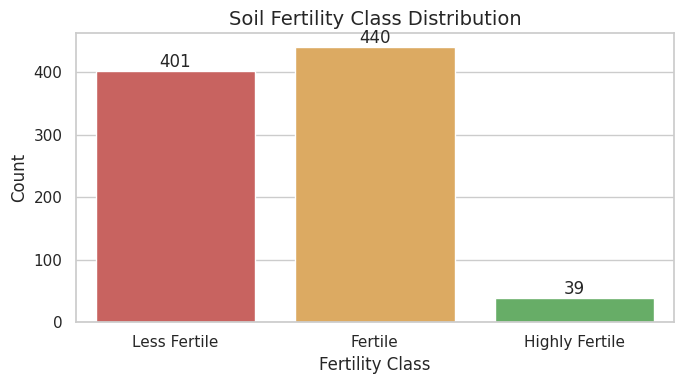

In [49]:
label_map = {0: 'Less Fertile', 1: 'Fertile', 2: 'Highly Fertile'}
df['Fertility_Label'] = df['Output'].map(label_map)

plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Fertility_Label', data=df,
                   order=['Less Fertile', 'Fertile', 'Highly Fertile'],
                   palette=['#d9534f', '#f0ad4e', '#5cb85c'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.title('Soil Fertility Class Distribution', fontsize=14)
plt.xlabel('Fertility Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/fertility_distribution.png', dpi=150)
plt.show()

## 5. Season Engineering
Since the dataset doesn't include season information, we engineer a **Season** feature based on Indian agricultural calendar:
- **Kharif** (June–Oct): High N, K (rice, maize, cotton)
- **Rabi** (Nov–Mar): High P, lower K (wheat, mustard)
- **Zaid** (Apr–May): Moderate nutrients (vegetables, melons)

Season
Kharif    612
Zaid      195
Rabi       73
Name: count, dtype: int64


/tmp/ipykernel_12015/3026644718.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season', data=df,


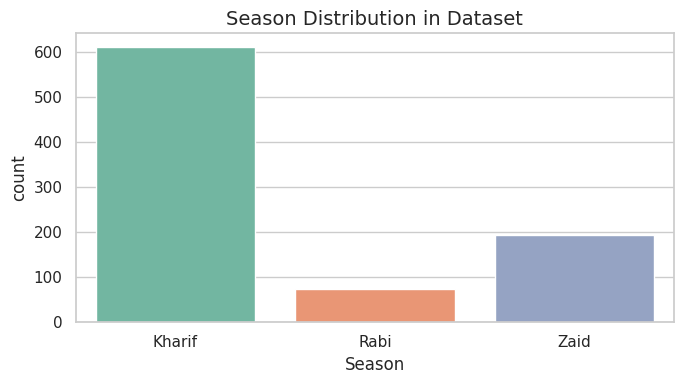

In [50]:
def assign_season(row):
    """Assign Indian agricultural season based on nutrient profile."""
    if row['N'] > 160 and row['K'] > 400:
        return 'Kharif'
    elif row['P'] > 8 and row['K'] <= 400:
        return 'Rabi'
    else:
        return 'Zaid'

df['Season'] = df.apply(assign_season, axis=1)
print(df['Season'].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(x='Season', data=df,
              order=['Kharif', 'Rabi', 'Zaid'],
              palette='Set2')
plt.title('Season Distribution in Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('../data/season_distribution.png', dpi=150)
plt.show()

## 6. Fertility Across Seasons

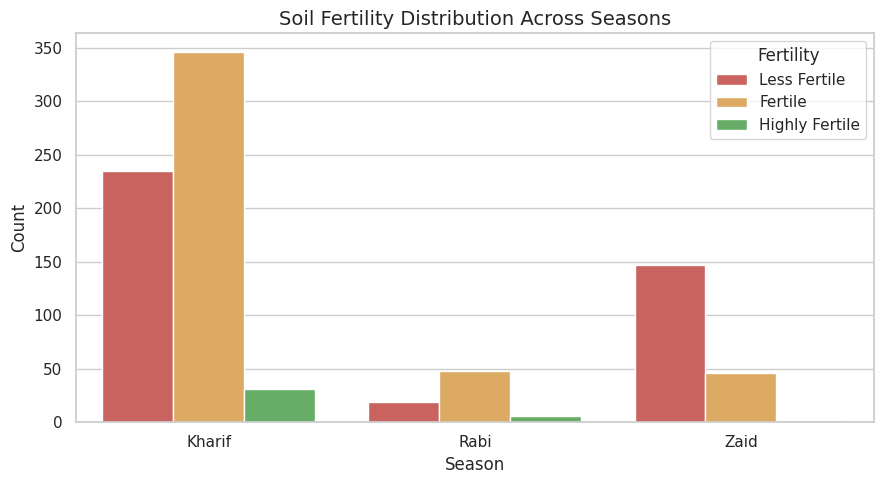

In [51]:
plt.figure(figsize=(9, 5))
sns.countplot(x='Season', hue='Fertility_Label', data=df,
              order=['Kharif', 'Rabi', 'Zaid'],
              hue_order=['Less Fertile', 'Fertile', 'Highly Fertile'],
              palette=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Soil Fertility Distribution Across Seasons', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Fertility')
plt.tight_layout()
plt.savefig('../data/fertility_by_season.png', dpi=150)
plt.show()

## 7. Correlation Heatmap

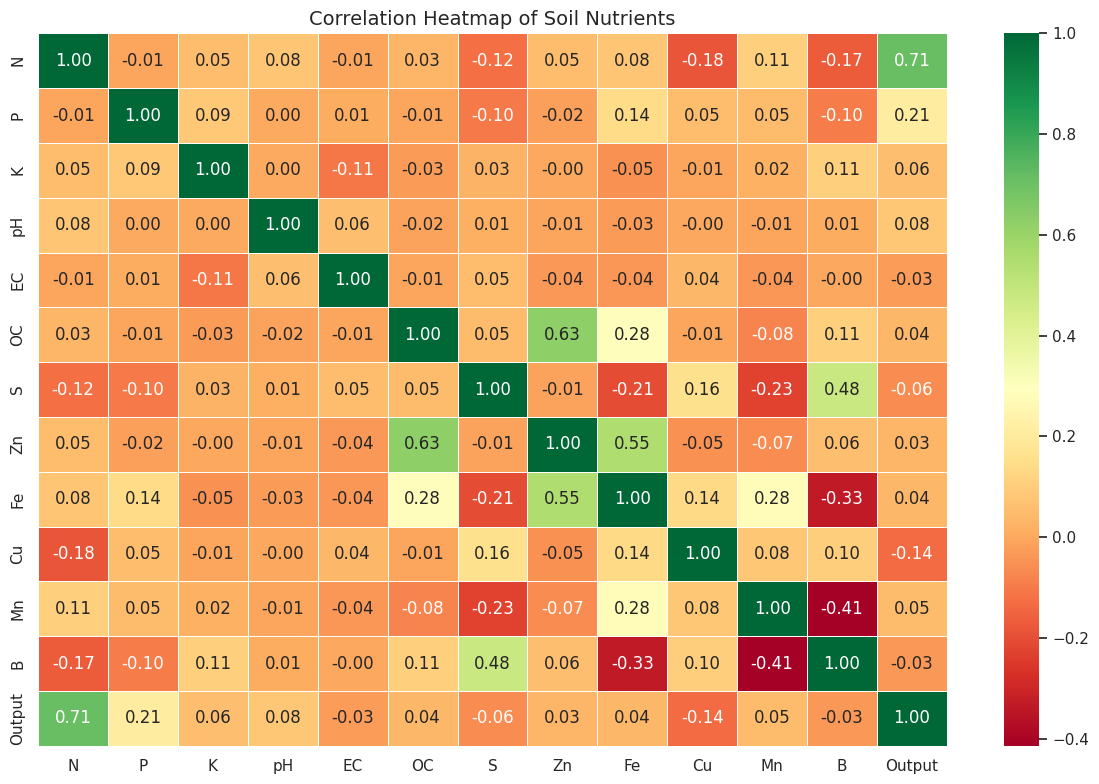

In [52]:
numeric_cols = ['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'Output']
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap of Soil Nutrients', fontsize=14)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

## 8. Nutrient Distributions by Fertility Class

/tmp/ipykernel_12015/1173651475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fertility_Label', y=col, data=df,
/tmp/ipykernel_12015/1173651475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fertility_Label', y=col, data=df,
/tmp/ipykernel_12015/1173651475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fertility_Label', y=col, data=df,
/tmp/ipykernel_12015/1173651475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

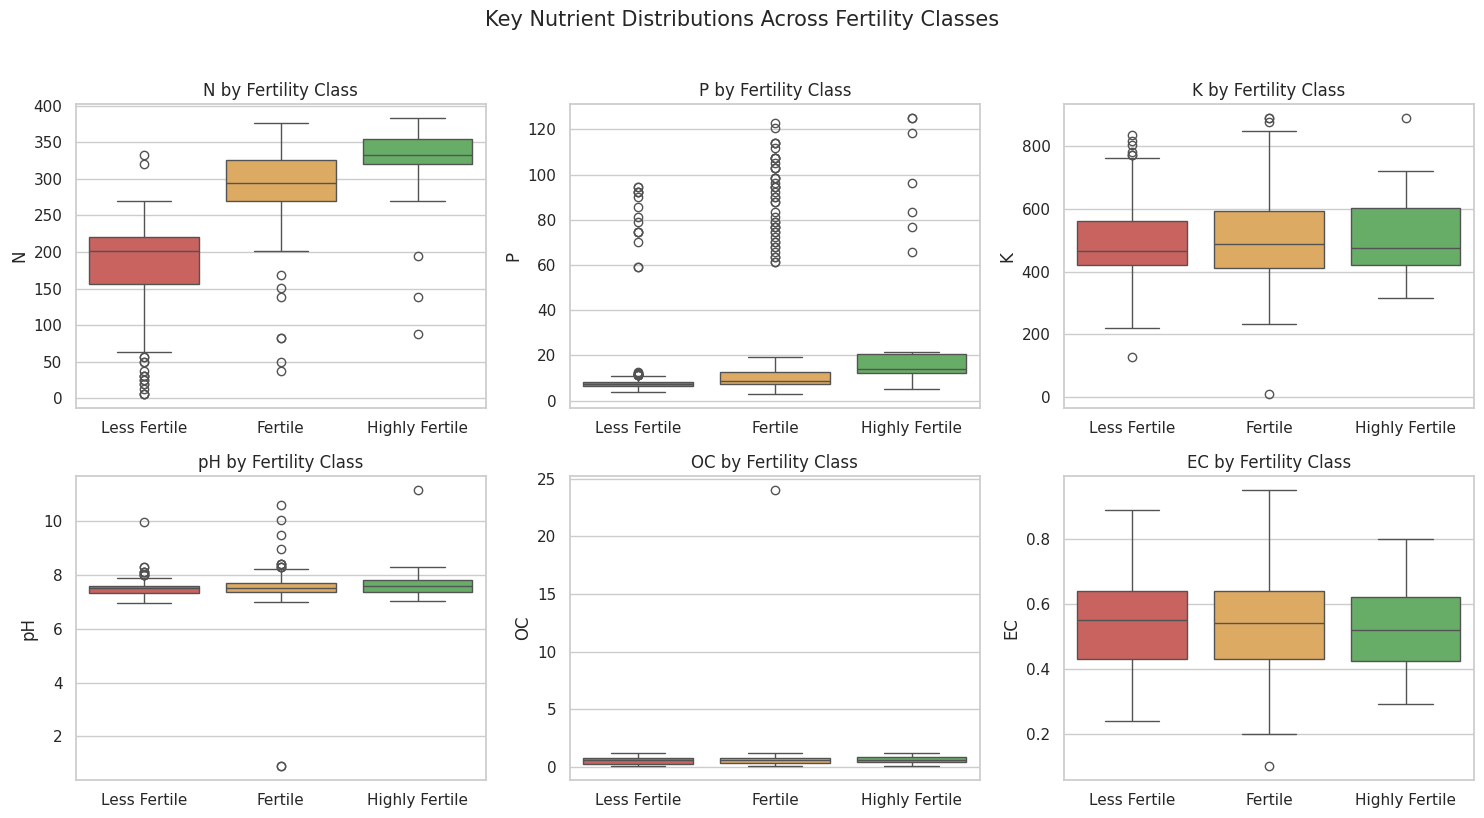

In [53]:
key_nutrients = ['N', 'P', 'K', 'pH', 'OC', 'EC']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_nutrients):
    sns.boxplot(x='Fertility_Label', y=col, data=df,
                order=['Less Fertile', 'Fertile', 'Highly Fertile'],
                palette=['#d9534f', '#f0ad4e', '#5cb85c'],
                ax=axes[i])
    axes[i].set_title(f'{col} by Fertility Class')
    axes[i].set_xlabel('')

plt.suptitle('Key Nutrient Distributions Across Fertility Classes', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../data/nutrient_boxplots.png', dpi=150)
plt.show()

## 9. Feature Engineering & Encoding

In [54]:
le = LabelEncoder()
df['Season_Encoded'] = le.fit_transform(df['Season'])
print('Season encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Save encoder for backend use
os.makedirs('../model', exist_ok=True)
joblib.dump(le, '../model/season_encoder.pkl')
print('Season encoder saved ✅')

Season encoding: {'Kharif': np.int64(0), 'Rabi': np.int64(1), 'Zaid': np.int64(2)}
Season encoder saved ✅


## 10. Train / Test Split

In [55]:
FEATURES = ['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'Season_Encoded']
TARGET = 'Output'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (704, 13), Test: (176, 13)


## 11. Model Training — Random Forest

In [56]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('Model trained ✅')

Model trained ✅


## 12. Evaluation

In [57]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Less Fertile', 'Fertile', 'Highly Fertile']))

Accuracy: 88.64%

Classification Report:
                precision    recall  f1-score   support

  Less Fertile       0.91      0.93      0.92        80
       Fertile       0.87      0.93      0.90        88
Highly Fertile       0.00      0.00      0.00         8

      accuracy                           0.89       176
     macro avg       0.60      0.62      0.61       176
  weighted avg       0.85      0.89      0.87       176



## 13. Confusion Matrix

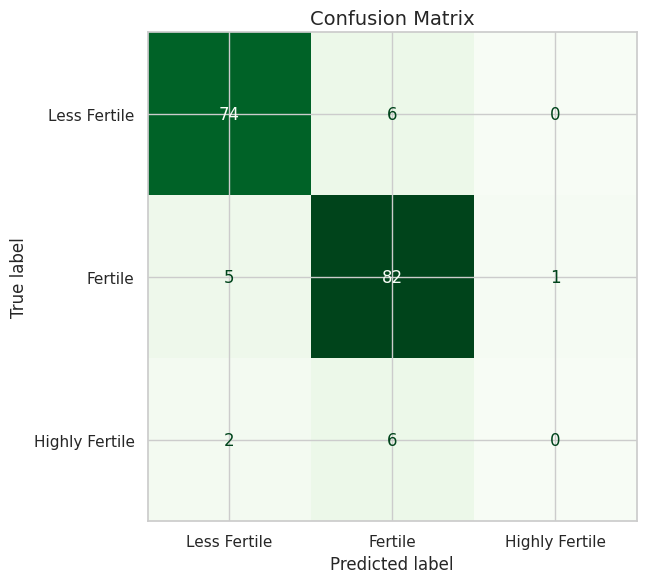

In [58]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Less Fertile', 'Fertile', 'Highly Fertile']
)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

## 14. Feature Importance

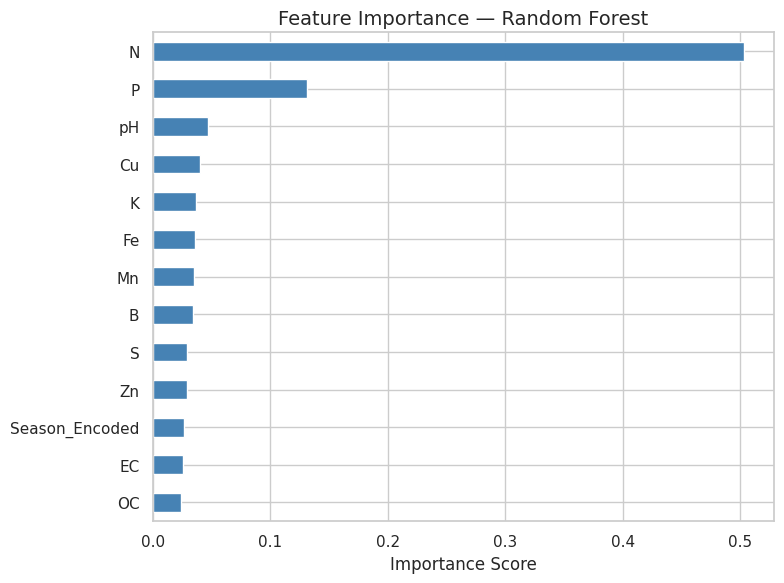

In [59]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

## 15. Save Model

In [60]:
joblib.dump(model, '../model/model.pkl')
print('Model saved to ../model/model.pkl ✅')

# Save feature names for backend validation
import json
with open('../model/features.json', 'w') as f:
    json.dump(FEATURES, f)
print('Feature list saved to ../model/features.json ✅')

Model saved to ../model/model.pkl ✅
Feature list saved to ../model/features.json ✅


✅ Done!
- EDA completed
- Season feature engineered
- Random Forest model trained and evaluated


